In [1]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.util import merge_dims


In [2]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [3]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


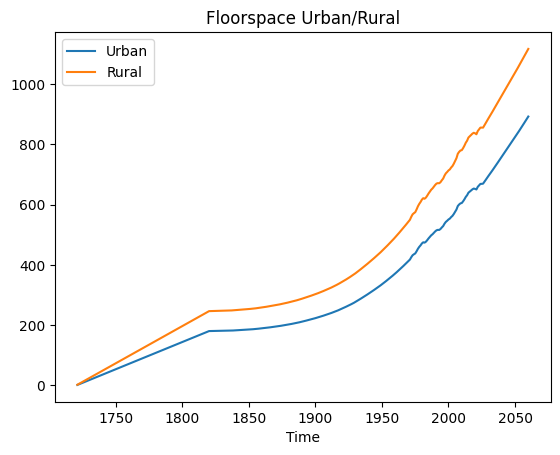

In [4]:
# Rural/Urban floorspace [Year, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})
floorspace_rururb.sum("Region").sel(Area="Urban").plot(label="Urban")
floorspace_rururb.sum("Region").sel(Area="Rural").plot(label="Rural")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [5]:
# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})

#for commercial_type in floorspace_commercial.coords["Type"].values:
#    floorspace_commercial.sum("Region").sel(Type=commercial_type).plot(label=commercial_type)
    
#plt.legend()
#plt.title("Floorspace commercial")
#plt.show()

In [100]:
from imagematerials.read_mym import read_mym_df
import pandas as pd

# import total population 1971 - 2100 from IMAGE
population_1970_future_df: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "pop.scn"))
population_1970_future_df = population_1970_future_df.loc[:, :26]

#rural population total meaning [Million]: the total of people living in rural areas (over time, by region)
rural_population: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "RURPOPTOT.out"))

#urban population total meaning [Million]: the total of people living in urban areas (over time, by region)
urban_population: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "URBPOPTOT.out"))

# remove emty and global region
rural_population, urban_population = rural_population.loc[:, :26], urban_population.loc[:, :26]

# read in historic global population from Maddison Project Database 2020 & 1700 value from https://www.johnstonsarchive.net/other/worldpop.html in 1000 people
historic_pop = pd.read_csv(base_directory / 'buildings' / 'standard_data' / 'historic_population.csv', index_col=0, header = 0)
historic_pop = historic_pop.loc[:1971] / 1000 # unit conversion

# interpolate for missing years from 1970 - 1700
all_years_historic_pop = range(historic_pop.index.min(), historic_pop.index.max() + 1)
historic_pop = historic_pop.reindex(all_years_historic_pop).interpolate(method="linear") # with cubic interpolation we see a drop at 1700

# regionalize data to IMAGE regions accoring to 1971 regionalization
share_regionalization_1971 = population_1970_future_df.loc[1971]/population_1970_future_df.loc[1971].sum()

# create pd dataframe with regionalized total population based on shares in 1971
regionalized_total_pop = pd.DataFrame(index=historic_pop.index, columns=share_regionalization_1971.index)

for region in share_regionalization_1971.index:
    regionalized_total_pop[region] = historic_pop * share_regionalization_1971[region]

# split up in rural and urban
# get urban share for base year
urban_share = urban_population/population_1970_future_df
urban_share = urban_share_1971.reindex(all_years_historic_pop)
urban_share.loc[1820] = 0.07
urban_share.loc[1700] = 0

urban_share = urban_share.interpolate()





In [103]:
population_1970_future_df

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
time,,,,,,,,,,,,,,,,,,,,,
1971,21.88868,202.9079,51.89767,44.06660,98.76629,98.69305,72.56262,145.1282,88.02728,23.03144,...,69.87732,569.9992,48.66999,864.1837,168.8495,120.8964,106.78940,17.34836,166.1363,46.29390
1972,22.22222,205.2384,53.54343,45.02407,101.19440,100.84950,74.26316,148.7183,90.47132,23.69851,...,72.23176,582.8380,49.74522,884.1987,172.9305,124.1148,108.22040,17.74228,169.5598,47.73538
1973,22.50203,207.3148,55.22820,45.98110,103.66690,103.04390,76.02226,152.4995,92.97651,24.38251,...,74.67161,596.1075,50.78783,903.4708,177.0300,127.3812,109.67950,18.05049,173.9762,49.28611
1974,22.81243,209.2780,56.94588,46.93873,106.16740,105.28490,77.85539,156.4865,95.68684,25.07702,...,77.21381,609.7219,51.75634,921.6447,181.0843,130.6785,111.10000,18.34835,178.4912,50.91645
1975,23.13625,211.2745,58.69188,47.89626,108.70050,107.54900,79.95338,160.6874,98.46992,25.77796,...,79.86169,623.5242,52.65395,937.8603,184.9676,134.0077,112.41160,18.61040,183.0685,52.61979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,44.70413,406.9001,147.52920,108.11890,187.05680,238.88070,333.89740,1800.1000,851.89280,60.43518,...,420.41640,1429.0260,47.33247,859.8127,432.2571,296.5885,77.01277,45.89003,831.9905,518.17220
2097,44.63897,406.7181,147.19360,107.75770,185.93050,237.97520,333.71800,1806.5630,852.87150,60.11348,...,419.82400,1421.2780,46.86356,851.1552,430.4944,295.1754,76.47527,45.85939,831.6567,518.86230
2098,44.57382,406.5361,146.85800,107.39660,184.80430,237.06970,333.53870,1813.0260,853.85020,59.79177,...,419.23150,1413.5310,46.39465,842.4976,428.7317,293.7623,75.93777,45.82874,831.3229,519.55240


<Axes: xlabel='year'>

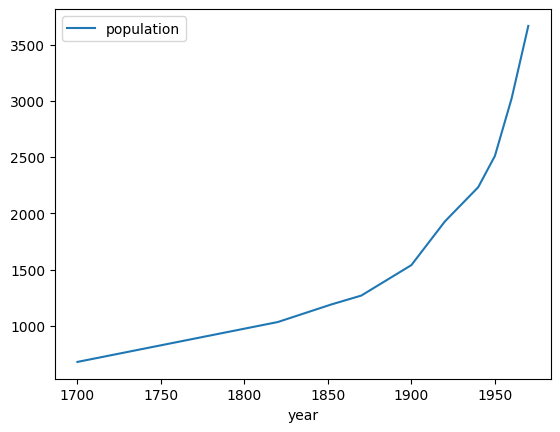

In [76]:
historic_pop.plot()



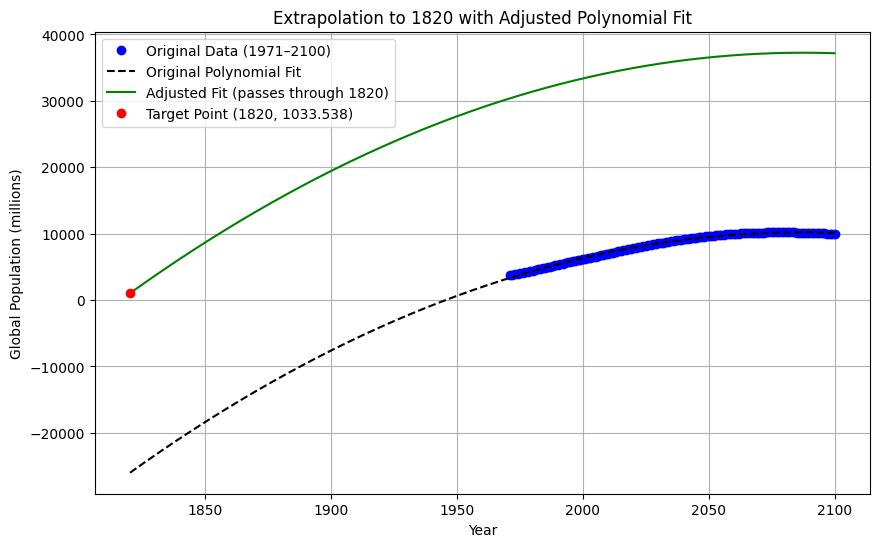

In [10]:
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# Assume this is your population data from 1971–2100
global_pop = population_1970_future_df.sum(axis=1)  # Series indexed by year

# 1. Get population data (1971–2100)
global_pop = population_1970_future_df.sum(axis=1)  # Pandas Series

# 2. Fit degree-2 polynomial to that range only
coeffs_original = np.polyfit(global_pop.index, global_pop.values, deg=2)
poly_original = np.poly1d(coeffs_original)

# 3. Compute the delta needed to match 1820 target
x_target = 1820
y_target = 1_033.538
y_current = poly_original(x_target)
delta = y_target - y_current

# 4. Create an adjusted copy of the polynomial without touching the original data
coeffs_adjusted = coeffs_original.copy()
coeffs_adjusted[-1] += delta  # adjust constant term
poly_adjusted = np.poly1d(coeffs_adjusted)

# Define a range covering 1820 to 2100
x_fit = np.linspace(1820, global_pop.index.max(), 500)

plt.figure(figsize=(10, 6))
plt.plot(global_pop.index, global_pop.values, 'bo', label='Original Data (1971–2100)')
plt.plot(x_fit, poly_original(x_fit), 'k--', label='Original Polynomial Fit')
plt.plot(x_fit, poly_adjusted(x_fit), 'g-', label='Adjusted Fit (passes through 1820)')
plt.plot(x_target, y_target, 'ro', label=f'Target Point (1820, {y_target})')
plt.xlabel('Year')
plt.ylabel('Global Population (millions)')
plt.title('Extrapolation to 1820 with Adjusted Polynomial Fit')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'poly' is not defined

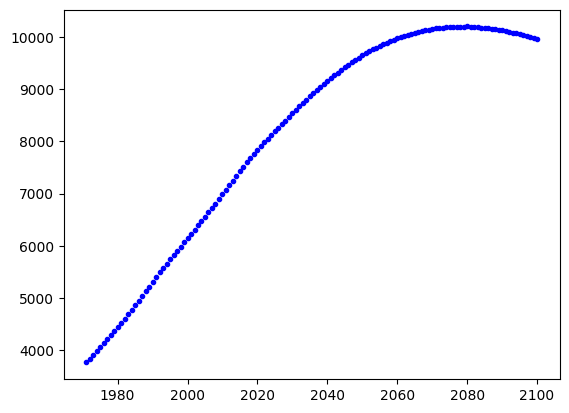

In [11]:
# Plot
plt.plot(global_pop.index, global_pop.values, 'b.', label='Data')
plt.plot(global_pop.index, poly(global_pop.index), 'g--', label='Poly Fit (deg=2)')
plt.legend()
plt.show()

poly_adjusted

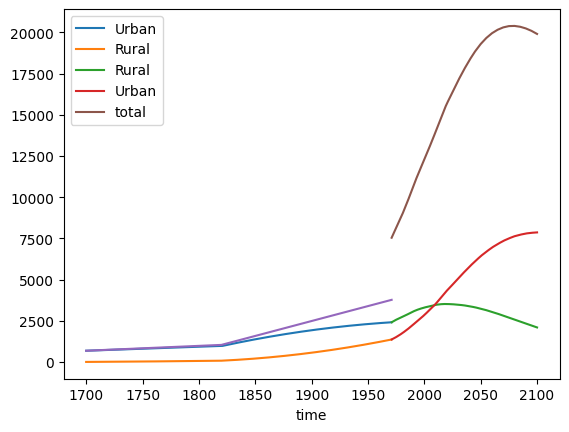

In [ ]:
urban_pop.sum(axis = 1).plot(label = 'Urban')
rural_pop.sum(axis = 1).plot(label = 'Rural')
rural_population.sum(axis = 1).plot(label = 'Rural')
urban_population.sum(axis = 1).plot(label = 'Urban')
total = (rural_pop.sum(axis = 1) + urban_pop.sum(axis = 1)).plot()
population_1970_future_df.sum(axis = 1).plot(label = 'total')

plt.legend()


In [ ]:
df = pd.DataFrame({
    'Rural': share_rural,
    'Urban': share_urban
})

# Create stacked area plot
df.plot.area(stacked=True)

plt.title("share Population Rural and Urban (in millions)")
plt.legend()


NameError: name 'share_rural' is not defined

In [ ]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [ ]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)

In [ ]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

In [ ]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb)

for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [ ]:

floorspace = xr.concat((floorspace_residential, floorspace_commercial), dim="Type")

In [ ]:
# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values)

In [ ]:
lifetimes["weibull"].coords["Type"]